# 📊 Exploratory Data Analysis
## BrownBox Customer Service Sentiment Classification

This notebook explores the customer service interaction dataset and analyses:
- Distribution of sentiment classes
- Feature distributions and their relationship with sentiment
- Conversation length statistics
- Correlation between features and sentiment


## 1. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = {'negative': '#E74C3C', 'neutral': '#3498DB', 'positive': '#2ECC71'}
COLORS  = list(PALETTE.values())




## 2. Load Data

In [4]:
import os

# Notebook is inside notebooks/ → go up one level to reach the CSV files
BASE = os.path.join(os.path.dirname(os.getcwd()), '')  # project root
# Fallback: hardcoded relative path
TRAIN_PATH = os.path.join(BASE, 'train.csv') if os.path.exists(os.path.join(BASE, 'train.csv')) else '../train.csv'
TEST_PATH  = os.path.join(BASE, 'test.csv')  if os.path.exists(os.path.join(BASE, 'test.csv'))  else '../test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test  shape: {test_df.shape}")
train_df.head(3)


Train shape: (970, 11)
Test  shape: (30, 11)


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...


## 3. Basic Dataset Information

In [5]:
print("=" * 50)
print("TRAIN - Column dtypes & null counts")
print("=" * 50)
info = pd.DataFrame({
    'dtype':     train_df.dtypes,
    'non_null':  train_df.notnull().sum(),
    'null':      train_df.isnull().sum(),
    'null_%':    (train_df.isnull().mean() * 100).round(2),
    'unique':    train_df.nunique()
})
print(info.to_string())


TRAIN - Column dtypes & null counts
                            dtype  non_null  null  null_%  unique
issue_area                    str       970     0     0.0       6
issue_category                str       970     0     0.0      40
issue_sub_category            str       970     0     0.0     109
issue_category_sub_category   str       970     0     0.0     109
customer_sentiment            str       970     0     0.0       3
product_category              str       970     0     0.0       3
product_sub_category          str       970     0     0.0      50
issue_complexity              str       970     0     0.0       3
agent_experience_level        str       970     0     0.0       3
agent_experience_level_desc   str       970     0     0.0       3
conversation                  str       970     0     0.0     968


In [ ]:
print("\nBasic statistics for conversation column:")
train_df['conv_len'] = train_df['conversation'].str.len() #counts the characters
train_df['conv_words'] = train_df['conversation'].str.split().str.len() #counts the words
print(train_df[['conv_len', 'conv_words']].describe().round(1))



Basic statistics for conversation column:
       conv_len  conv_words
count     970.0       970.0
mean     2129.3       370.9
std       564.8        98.3
min        46.0         8.0
25%      1760.2       306.0
50%      2058.5       357.0
75%      2430.0       424.0
max      5708.0       992.0


## 4. Sentiment Class Distribution




I looked at the distribution of customer sentiment class to understand class imbalance.

In [10]:
sent_counts = train_df['customer_sentiment'].value_counts()
sent_pct    = train_df['customer_sentiment'].value_counts(normalize=True) * 100

print("Sentiment distribution in TRAIN set:")
print(pd.DataFrame({'Count': sent_counts, 'Percentage (%)': sent_pct.round(2)}))
print()
print("Sentiment distribution in TEST set:")
test_sent   = test_df['customer_sentiment'].value_counts()
test_sent_pct = test_df['customer_sentiment'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': test_sent, 'Percentage (%)': test_sent_pct.round(2)}))


Sentiment distribution in TRAIN set:
                    Count  Percentage (%)
customer_sentiment                       
neutral               542           55.88
negative              411           42.37
positive               17            1.75

Sentiment distribution in TEST set:
                    Count  Percentage (%)
customer_sentiment                       
negative               10           33.33
neutral                10           33.33
positive               10           33.33


The training set is severely imbalanced — the 'positive' class 
has only 17 samples (1.75%). The test set, however, is perfectly balanced 
(33.33% each). This discrepancy means:
- Accuracy is not a reliable metric → Macro-F1 should be the primary metric
- Class weights will be applied during training to handle the imbalance

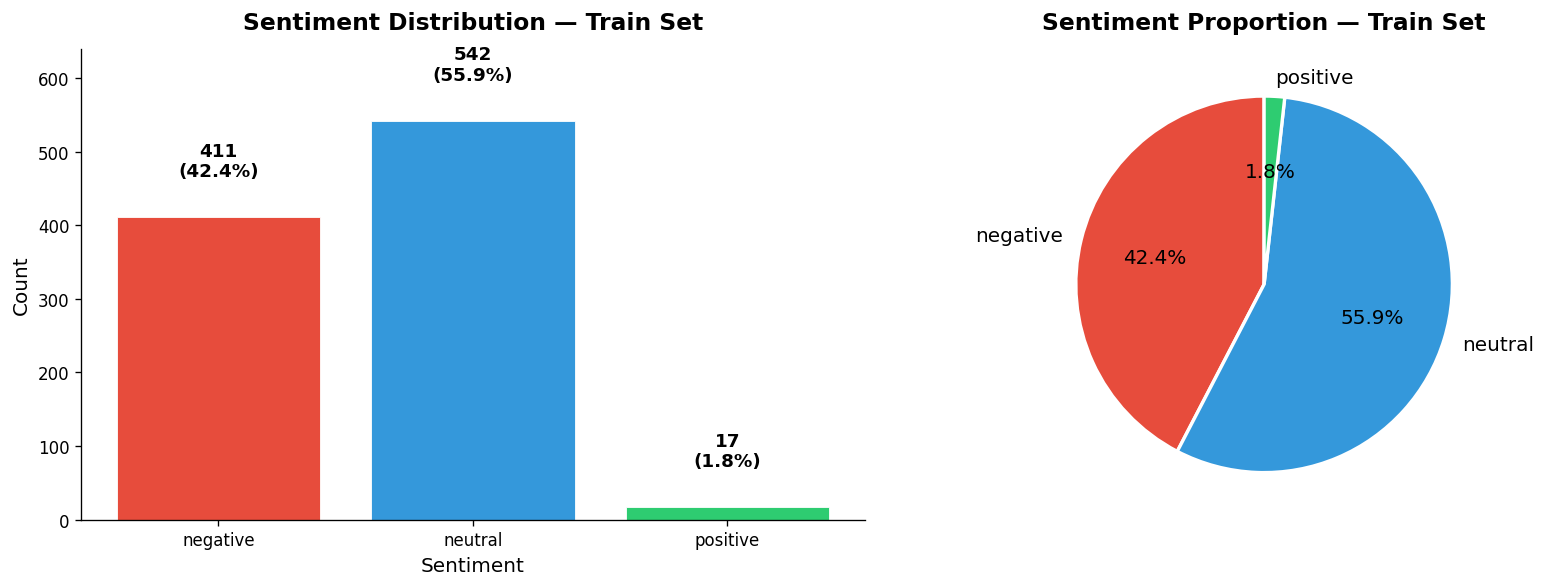

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
order = ['negative', 'neutral', 'positive']
bar_colors = [PALETTE[s] for s in order]
axes[0].bar(order, [sent_counts.get(s, 0) for s in order], color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Sentiment Distribution — Train Set', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, (s, c) in enumerate(zip(order, [sent_counts.get(s, 0) for s in order])):
    axes[0].text(i, c + 50, f'{c:,}\n({c/len(train_df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(sent_counts) * 1.18)

# Pie chart
wedge_sizes = [sent_counts.get(s, 0) for s in order]
axes[1].pie(wedge_sizes, labels=order, colors=bar_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 12})
axes[1].set_title('Sentiment Proportion — Train Set', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()



## 5. Categorical Feature Distributions

We explore each metadata feature individually to understand the dataset composition.


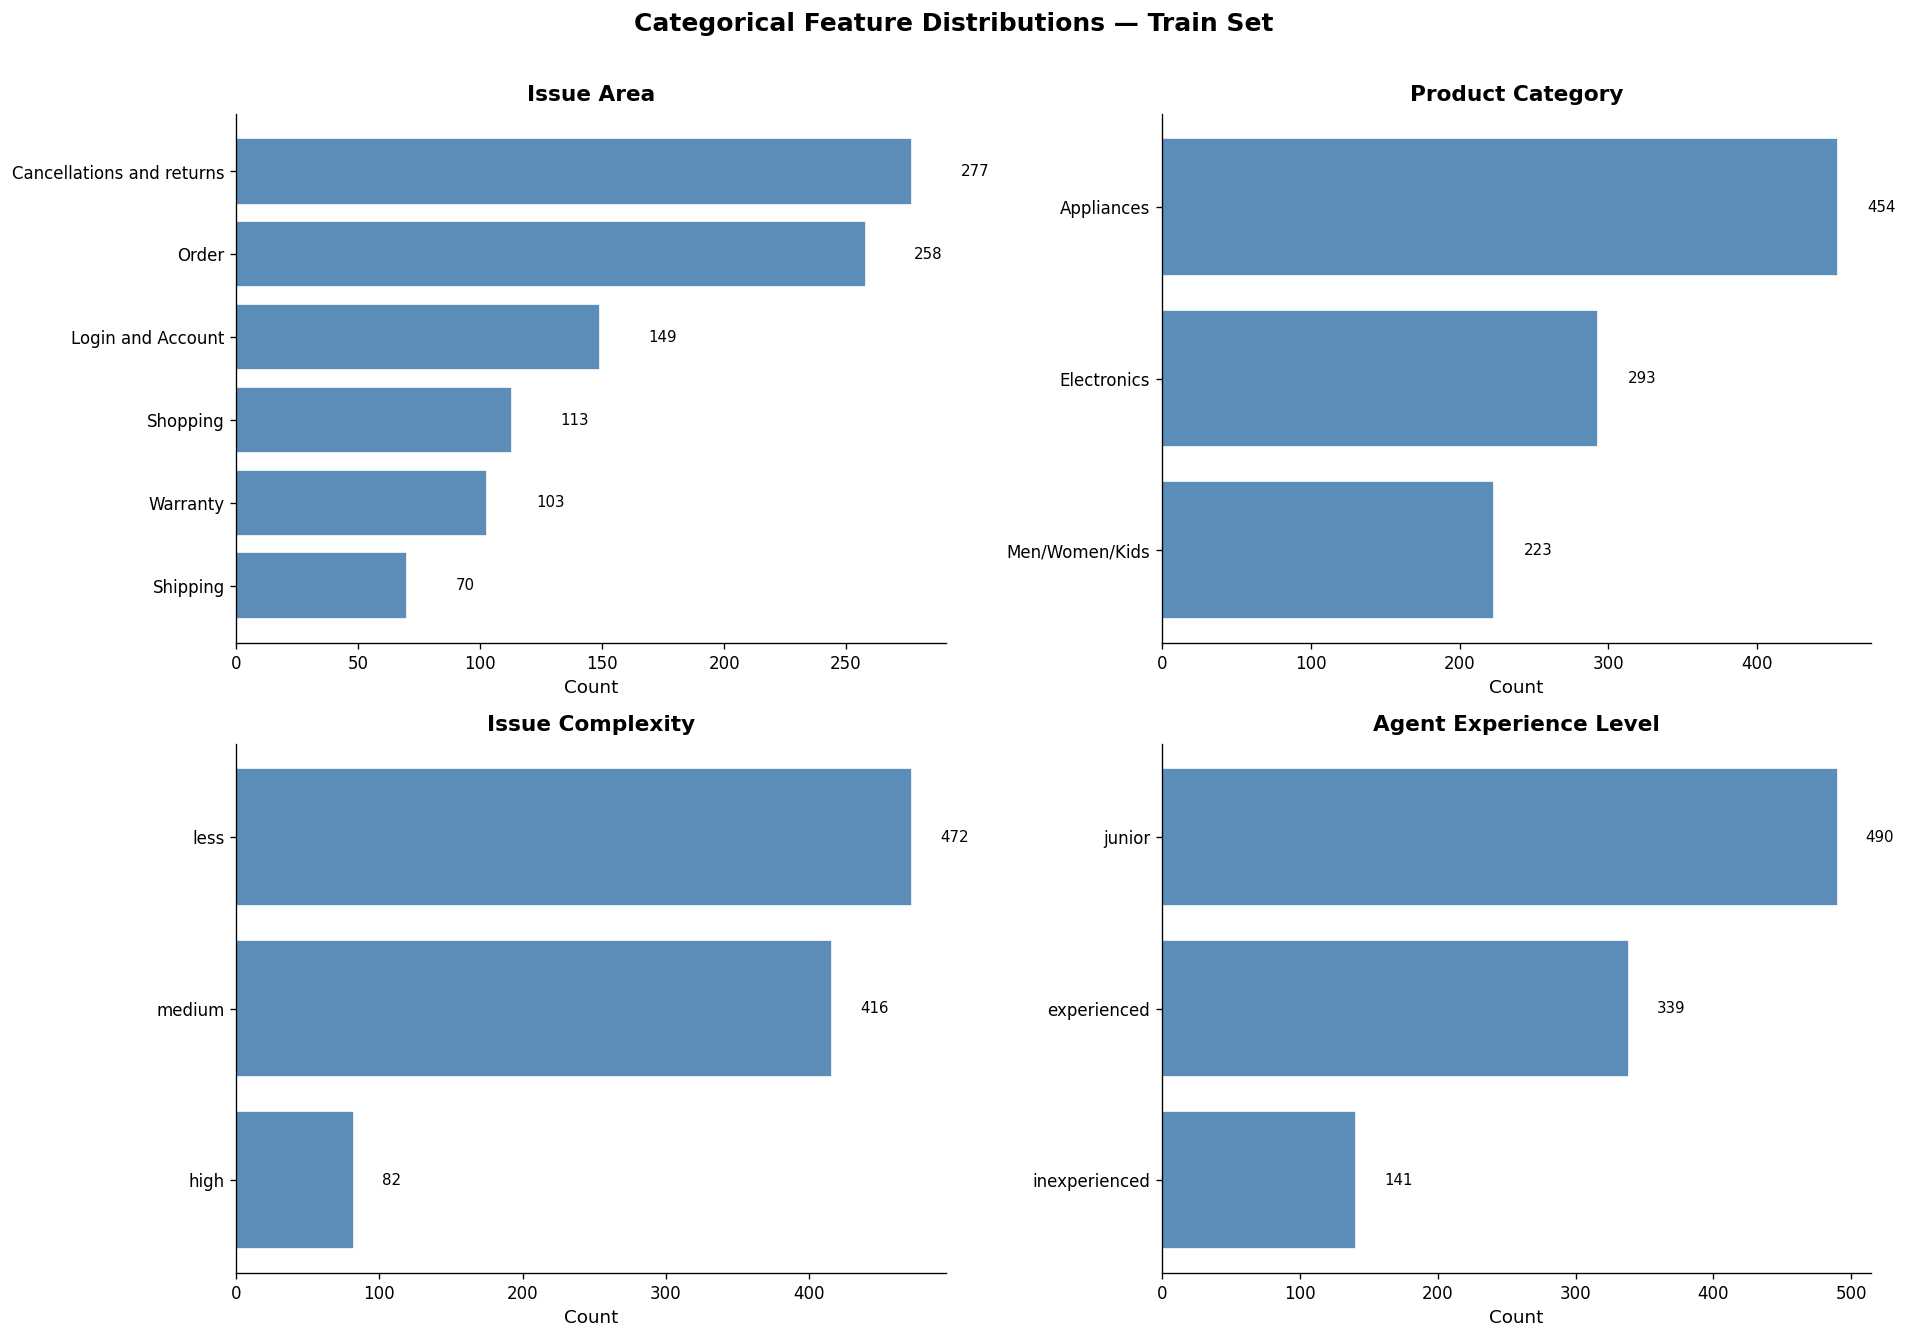

In [15]:
cat_features = ['issue_area', 'product_category', 'issue_complexity', 'agent_experience_level']
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, feat in zip(axes, cat_features):
    vc = train_df[feat].value_counts()
    bars = ax.barh(vc.index, vc.values, color='#5B8DB8', edgecolor='white')
    ax.set_title(f'{feat.replace("_", " ").title()}', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Count', fontsize=11)
    for bar, val in zip(bars, vc.values):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Categorical Feature Distributions — Train Set', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()


## 6. Feature vs Sentiment Correlation

Cross-tabulations and stacked bar charts reveal how each feature relates to sentiment.


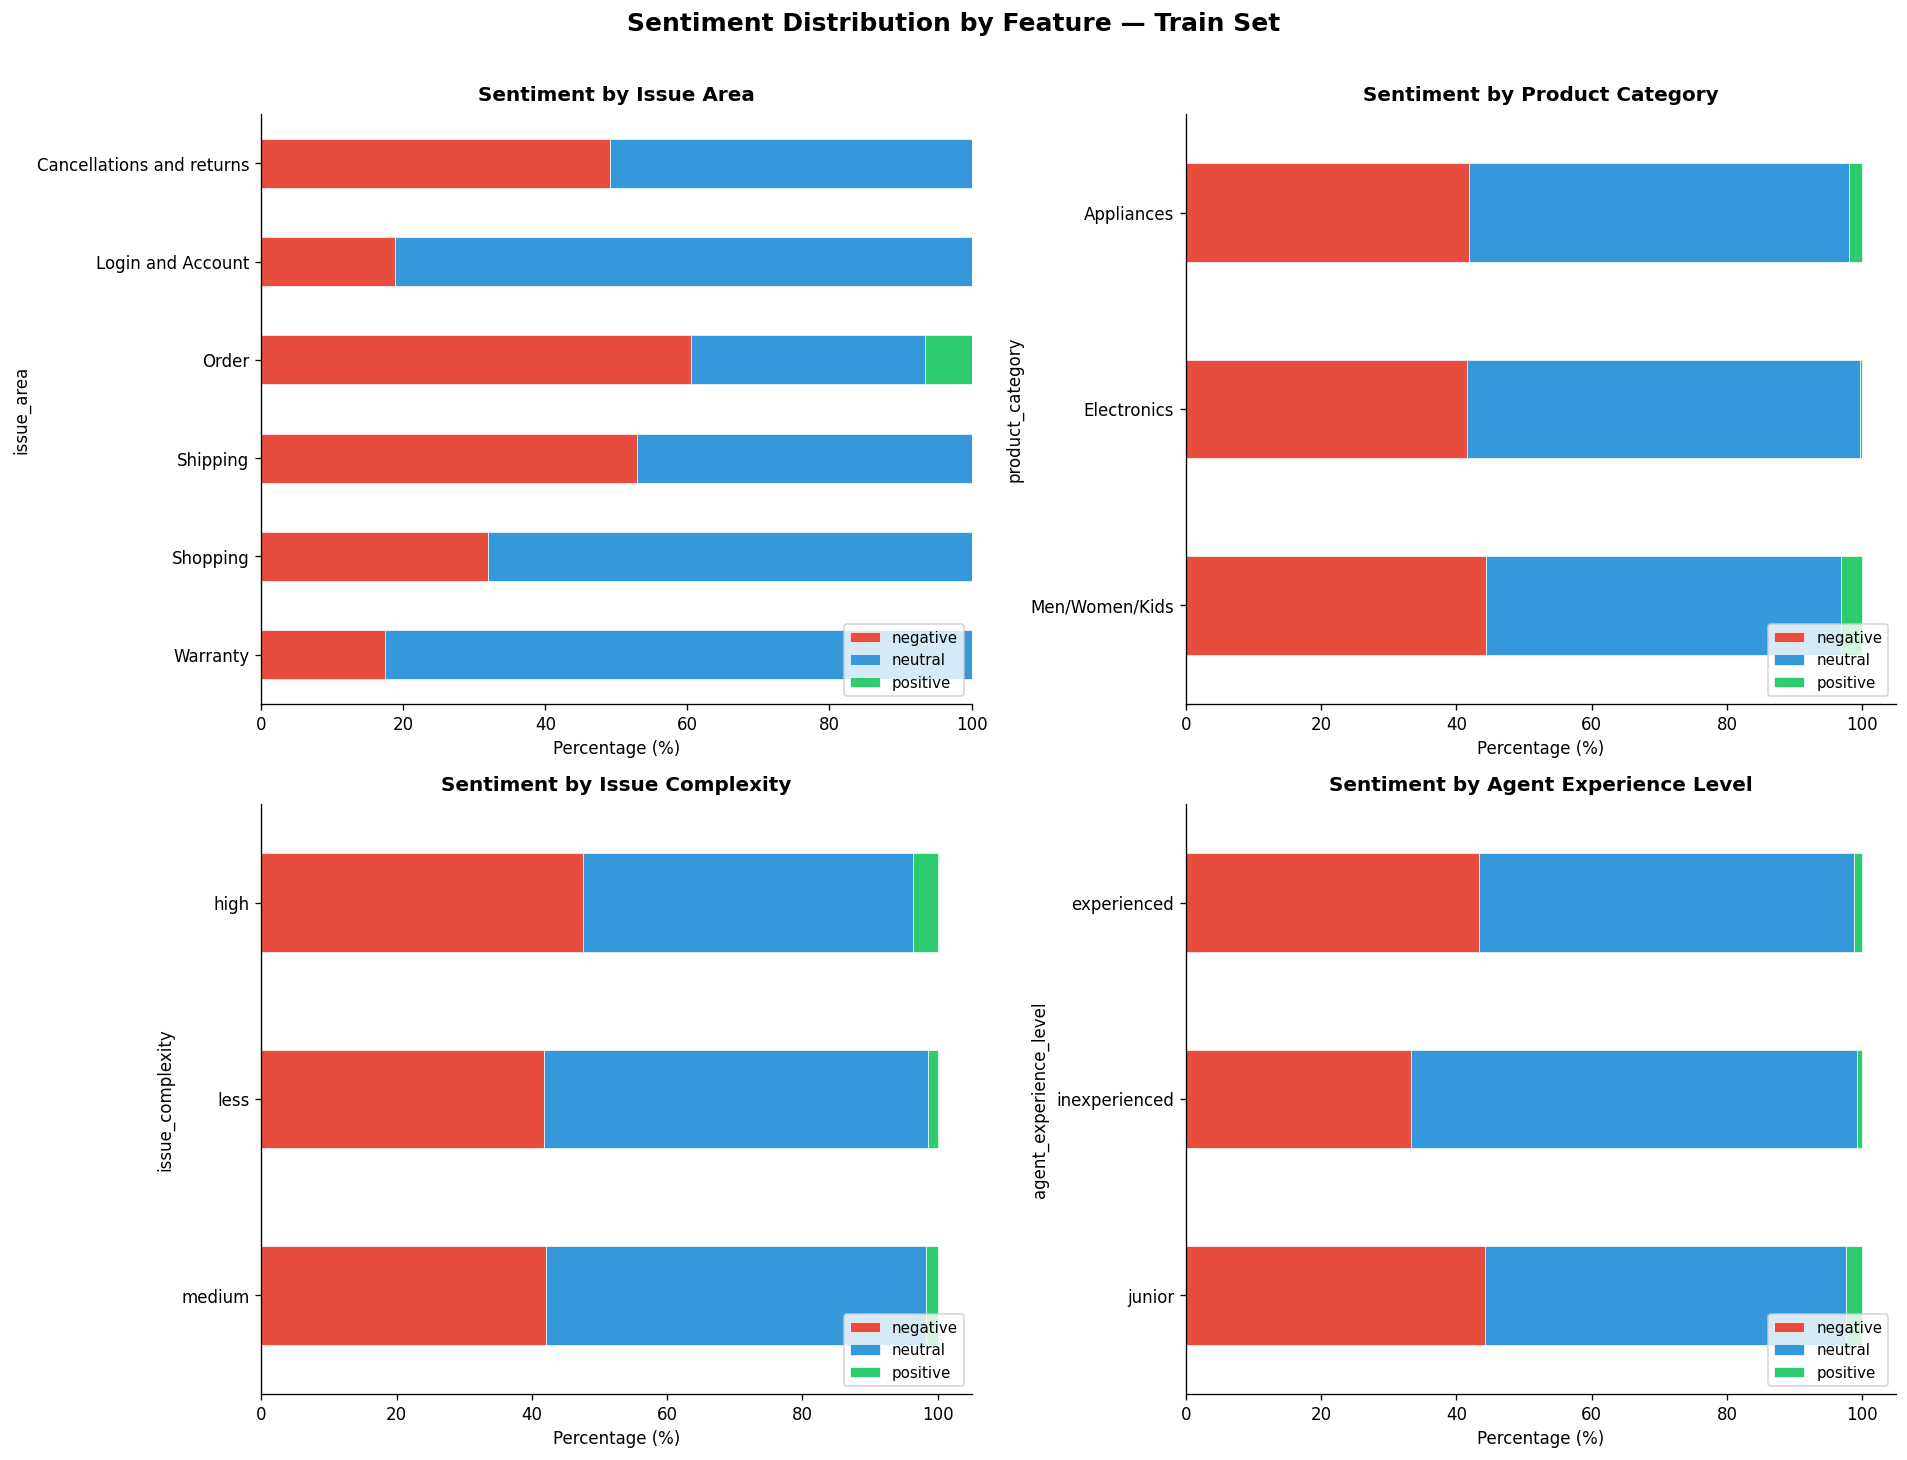

In [16]:
def plot_sentiment_by_feature(df, feature, ax, top_n=10):
    """Stacked horizontal bar chart: sentiment breakdown per feature category."""
    ct = pd.crosstab(df[feature], df['customer_sentiment'], normalize='index') * 100
    ct = ct.reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)
    # keep top_n categories by count
    top_cats = df[feature].value_counts().head(top_n).index
    ct = ct.loc[ct.index.isin(top_cats)]
    ct.plot(kind='barh', stacked=True, ax=ax,
            color=[PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']],
            edgecolor='white', linewidth=0.4)
    ax.set_title(f'Sentiment by {feature.replace("_", " ").title()}',
                 fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Percentage (%)', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.invert_yaxis()

features_to_plot = ['issue_area', 'product_category', 'issue_complexity', 'agent_experience_level']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    plot_sentiment_by_feature(train_df, feat, ax)

plt.suptitle('Sentiment Distribution by Feature — Train Set', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sentiment_by_feature.png', bbox_inches='tight')
plt.show()



## 7. Cramér's V — Feature–Sentiment Association

Cramér's V measures the **association between two categorical variables** (0 = no association, 1 = perfect association). It is the appropriate metric when both variables are categorical.


Cramér's V with customer_sentiment:
issue_sub_category        1.0000
issue_category            0.7389
issue_area                0.2951
product_sub_category      0.2133
agent_experience_level    0.0691
product_category          0.0597
issue_complexity          0.0412


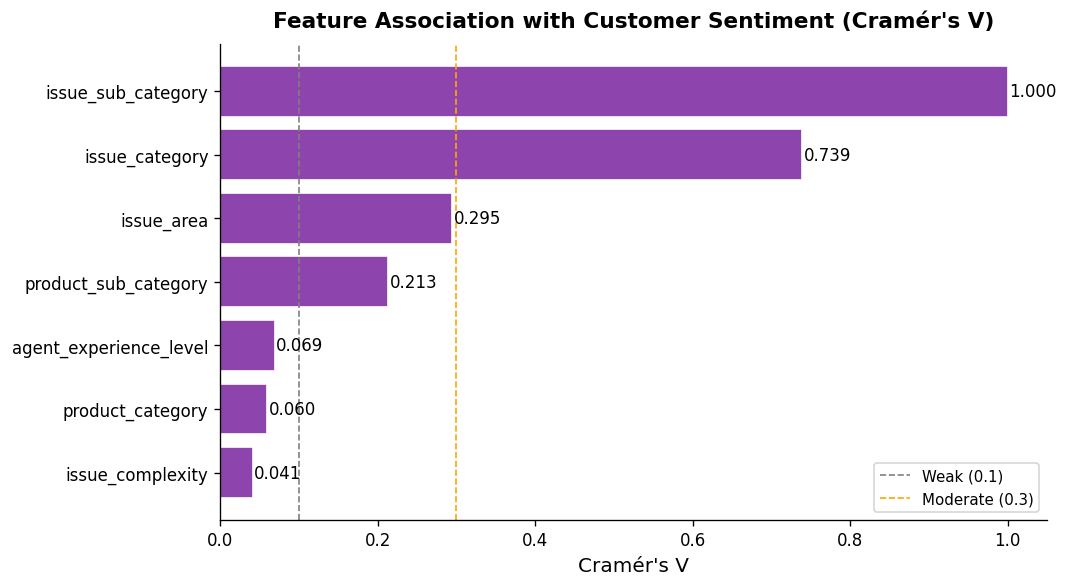

In [18]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Compute Cramér's V between two categorical series."""
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

features = ['issue_area', 'issue_category', 'issue_sub_category',
            'product_category', 'product_sub_category',
            'issue_complexity', 'agent_experience_level']

results = {f: cramers_v(train_df[f], train_df['customer_sentiment']) for f in features}
cv_df = pd.Series(results).sort_values(ascending=False).rename("Cramér's V")

print("Cramér's V with customer_sentiment:")
print(cv_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cv_df.index, cv_df.values, color='#8E44AD', edgecolor='white')
ax.set_xlabel("Cramér's V", fontsize=12)
ax.set_title("Feature Association with Customer Sentiment (Cramér's V)", fontsize=13, fontweight='bold', pad=10)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='Weak (0.1)')
ax.axvline(0.3, color='orange', linestyle='--', linewidth=1, label='Moderate (0.3)')
for bar, val in zip(bars, cv_df.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('cramers_v.png', bbox_inches='tight')
plt.show()



## 8. Conversation Length Analysis

Understanding token counts helps to justify preprocessing strategy.


In [ ]:
def extract_customer_lines(conversation):
    """Extract only 'Customer:' turns from conversation."""
    lines = str(conversation).split('\n')
    customer_lines = [
        line.replace('Customer:', '').strip()
        for line in lines
        if line.strip().startswith('Customer:')
    ]
    return ' '.join(customer_lines)

train_df['customer_text']   = train_df['conversation'].apply(extract_customer_lines)
train_df['full_word_count'] = train_df['conversation'].str.split().str.len()
train_df['cust_word_count'] = train_df['customer_text'].str.split().str.len()

# Rough BERT token estimate: 1.3 tokens/word
train_df['full_tokens'] = (train_df['full_word_count'] * 1.3).astype(int)
train_df['cust_tokens'] = (train_df['cust_word_count'] * 1.3).astype(int)

print("=== Full Conversation Token Stats ===")
print(train_df['full_tokens'].describe().round(1))
print()
print("=== Customer-Only Token Stats ===")
print(train_df['cust_tokens'].describe().round(1))
print()
print(f"Full conv  >= 512 tokens: {(train_df['full_tokens'] >= 512).mean()*100:.1f}%")
print(f"Cust-only  >= 512 tokens: {(train_df['cust_tokens'] >= 512).mean()*100:.1f}%")


=== Full Conversation Token Stats ===
count     970.0
mean      481.7
std       127.8
min        10.0
25%       397.0
50%       464.0
75%       551.0
max      1289.0
Name: full_tokens, dtype: float64

=== Customer-Only Token Stats ===
count    970.0
mean     127.5
std       34.9
min        0.0
25%      105.0
50%      124.0
75%      145.0
max      351.0
Name: cust_tokens, dtype: float64

Full conv  >= 512 tokens: 34.7%
Cust-only  >= 512 tokens: 0.0%


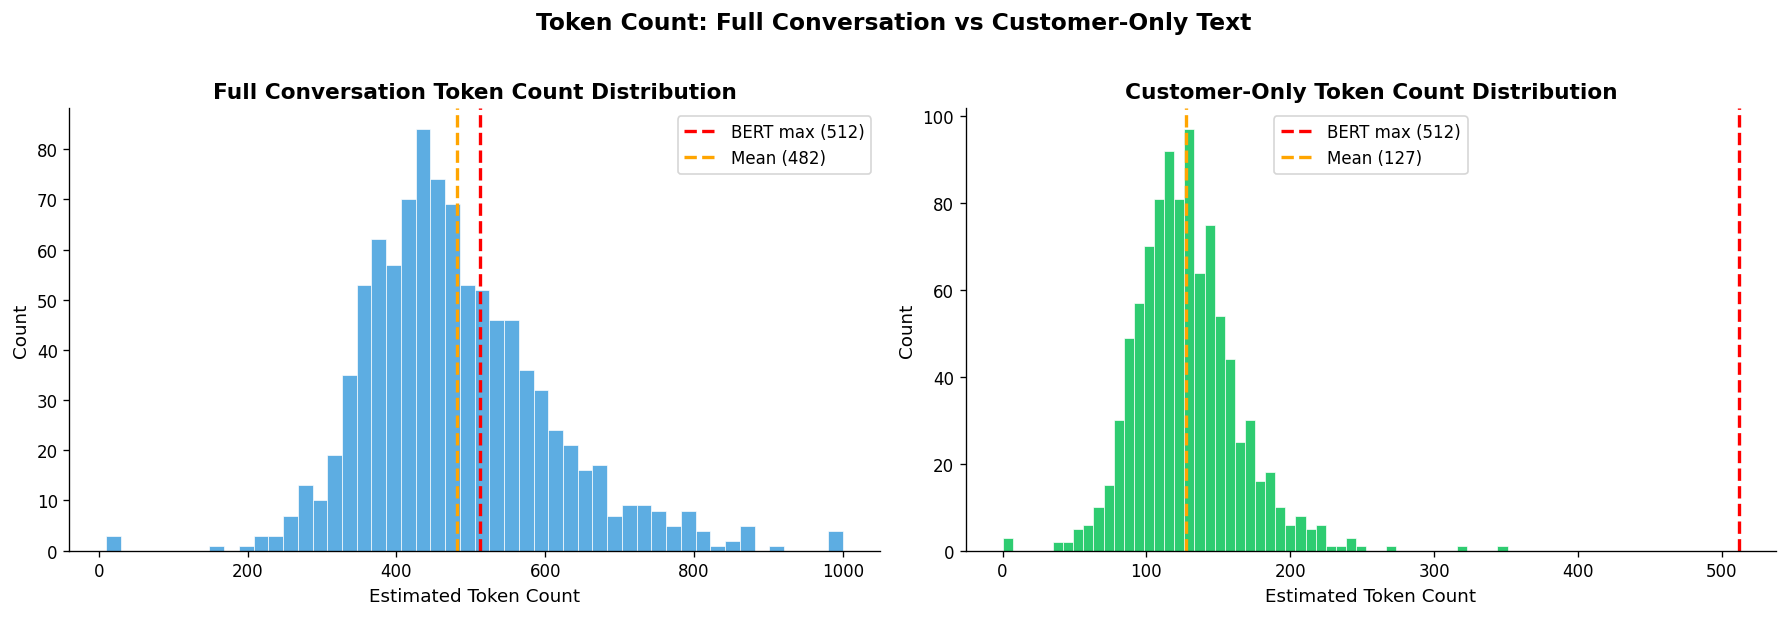

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of full conversation tokens
axes[0].hist(train_df['full_tokens'].clip(upper=1000), bins=50, color='#5DADE2', edgecolor='white', linewidth=0.4)
axes[0].axvline(512, color='red', linestyle='--', linewidth=2, label='BERT max (512)')
axes[0].axvline(train_df['full_tokens'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean ({train_df["full_tokens"].mean():.0f})')
axes[0].set_title('Full Conversation Token Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estimated Token Count', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)

# Distribution of customer-only tokens
axes[1].hist(train_df['cust_tokens'].clip(upper=600), bins=50, color='#2ECC71', edgecolor='white', linewidth=0.4)
axes[1].axvline(512, color='red', linestyle='--', linewidth=2, label='BERT max (512)')
axes[1].axvline(train_df['cust_tokens'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean ({train_df["cust_tokens"].mean():.0f})')
axes[1].set_title('Customer-Only Token Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estimated Token Count', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('Token Count: Full Conversation vs Customer-Only Text',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('token_distributions.png', bbox_inches='tight')
plt.show()



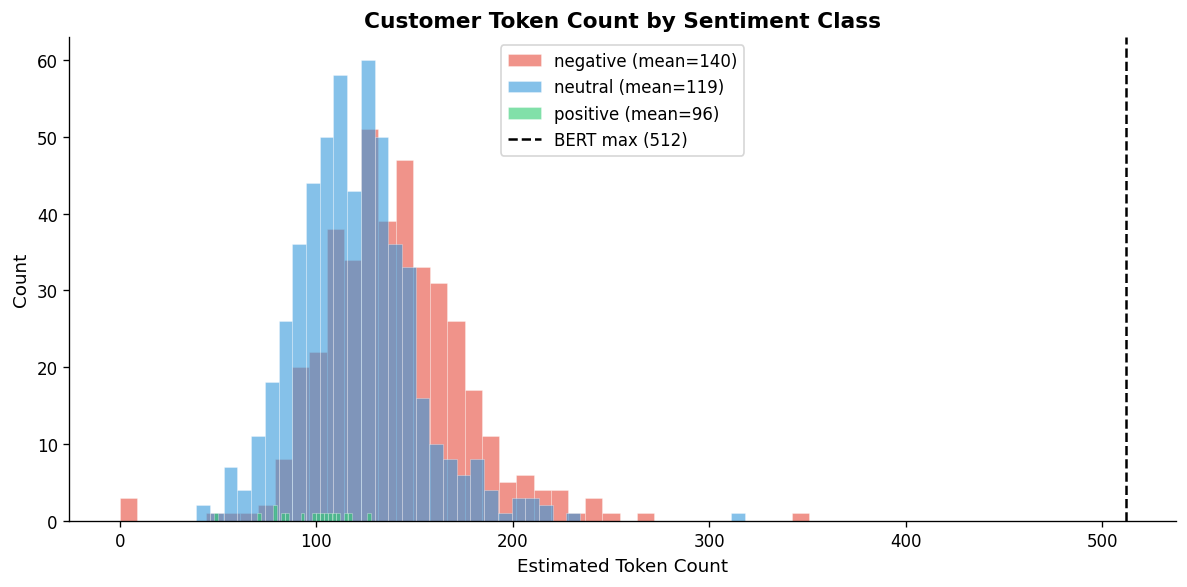

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
for sent, color in PALETTE.items():
    subset = train_df[train_df['customer_sentiment'] == sent]['cust_tokens']
    ax.hist(subset.clip(upper=500), bins=40, alpha=0.6, color=color,
            label=f'{sent} (mean={subset.mean():.0f})', edgecolor='white', linewidth=0.3)
ax.axvline(512, color='black', linestyle='--', linewidth=1.5, label='BERT max (512)')
ax.set_title('Customer Token Count by Sentiment Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Estimated Token Count', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('tokens_by_sentiment.png', bbox_inches='tight')
plt.show()


## 9. Sentiment Heatmap by Issue Area & Complexity

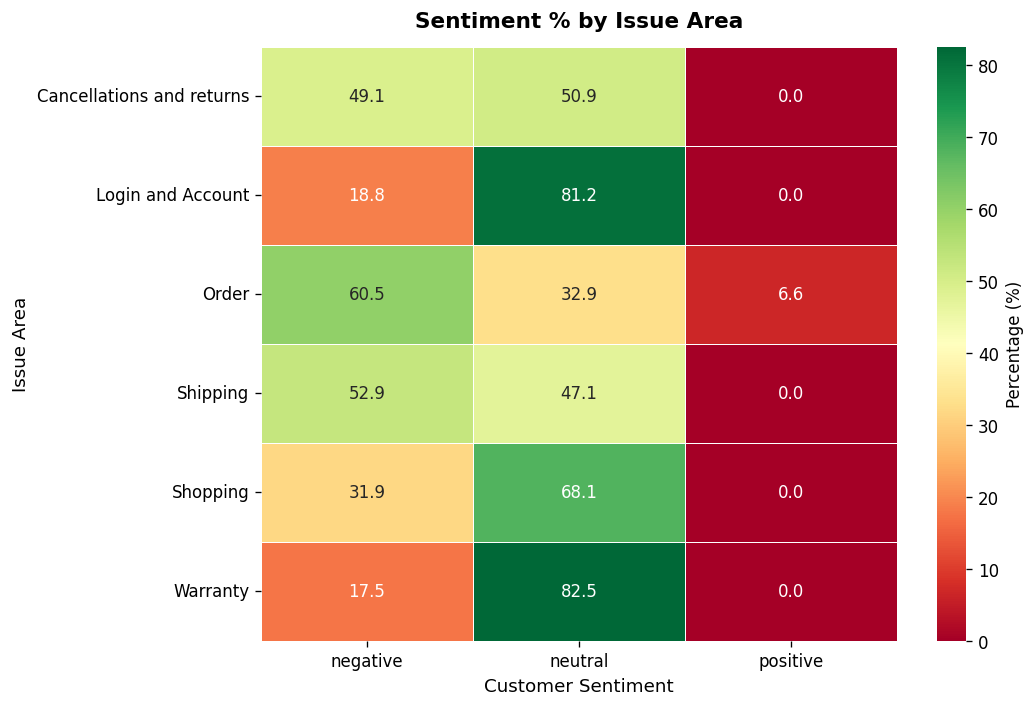

In [29]:
pivot = pd.crosstab(train_df['issue_area'], train_df['customer_sentiment'], normalize='index') * 100
pivot = pivot.reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title('Sentiment % by Issue Area', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Customer Sentiment', fontsize=11)
ax.set_ylabel('Issue Area', fontsize=11)
plt.tight_layout()
plt.savefig('heatmap_issue_area.png', bbox_inches='tight')
plt.show()

